In [1]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
import sys
sys.path.append('../../pybeh')
sys.path.append('../../CourierReinstate1')
import cmlreaders as cml
from cmldask import CMLDask as da
from dask.distributed import wait, as_completed
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd
import xarray as xr
import pandas_to_pybeh as pb
import scipy as scp
import re
import math
import pickle
import gc
from scipy import stats
from ptsa.data.filters import ButterworthFilter, MorletWaveletFilter
from statsmodels.stats.multitest import multipletests
from compute_scalp_features import create_baseline_events
from BehavioralFunctions import *

pd.options.display.max_rows = 100
pd.options.display.max_columns = 50
%matplotlib inline
import importlib
import statsmodels.api as sm
from statsmodels.stats.anova import AnovaRM

In [2]:
subjects = ['LTP606', 'LTP607', 'LTP609', 'LTP610', 'LTP612']
experiment = 'ValueCourier'

### Retrieval

In [3]:
RETR_REL_START = -900
RETR_REL_STOP = -200
DELIB_REL_START = -900
DELIB_REL_STOP = -200
BUFFER_MS_DELIB = 833.333333333

WIDTH = 6
FREQS = np.logspace(np.log10(2), np.log10(100), 46)
NOTCH_BAND = (58., 62.)
BATCH_EVENTS = 64
ROI_ORDER = ['LAI','RAI','LAS','RAS','LPS','RPS','LPI','RPI']

def assign_roi(channel):
    roi_dict = {
        'LAS':['C24','C25','D2','D3','D4','D11','D12','D13'],
        'LAI':['C31','C32','D5','D6','D9','D10','D21','D22'],
        'LPS':['D29','A5','A6','A7','A8','A17','A18'],
        'LPI':['D30','D31','A9','A10','A11','A15','A16'],
        'RAS':['B30','B31','B32','C2','C3','C4','C11','C12'],
        'RAI':['B24','B25','B28','B29','C5','C6','C9','C10'],
        'RPS':['A30','A31','A32','B3','B4','B5','B13'],
        'RPI':['A28','A29','B6','B7','B8','B11','B12'],
    }
    for roi, chans in roi_dict.items():
        if channel in chans:
            return roi
    return None

In [4]:
df_idx = cml.get_data_index('ltp').query("experiment == 'ValueCourier'").copy()
if subjects is not None:
    df_idx = df_idx[df_idx['subject'].isin(subjects)]
subjects = sorted(df_idx.subject.unique())

In [5]:
def welch_t_from_agg(n1, sum1, sumsq1, n0, sum0, sumsq0):
    with np.errstate(divide='ignore', invalid='ignore'):
        m1 = sum1 / np.maximum(n1, 1)
        m0 = sum0 / np.maximum(n0, 1)
        v1 = (sumsq1 - (sum1**2)/np.maximum(n1, 1)) / np.maximum(n1 - 1, 1)
        v0 = (sumsq0 - (sum0**2)/np.maximum(n0, 1)) / np.maximum(n0 - 1, 1)
        denom = np.sqrt(v1 / np.maximum(n1, 1) + v0 / np.maximum(n0, 1))
        t = (m1 - m0) / denom
        t[~np.isfinite(t)] = np.nan
    return t

In [6]:
def ensure_trial_col(df):
    if 'trial' in df.columns:
        return df
    for alt in ['list', 'trialno', 'trial_num', 'trial_number']:
        if alt in df.columns:
            return df.rename(columns={alt: 'trial'})
    g = df.groupby(['subject','session'], sort=False).cumcount()
    out = df.copy()
    out['trial'] = g
    return out

In [7]:
REQUIRED_NUMERIC = ['session', 'trial', 'mstime']
OPTIONAL_NUMERIC = ['intrusion', 'serialpos', 'repetition', 'itemno', 'list', 'eegoffset']
STRING_COLS = ['type', 'eegfile', 'phase']

def prep_for_baseline(evs: pd.DataFrame) -> pd.DataFrame:
    e = evs.replace(r'^\s*$', np.nan, regex=True)
    
    for col in REQUIRED_NUMERIC + OPTIONAL_NUMERIC:
        if col in e.columns:
            e[col] = pd.to_numeric(e[col], errors='coerce')

    if 'intrusion' in e.columns:
        e['intrusion'] = e['intrusion'].fillna(0)

    if not set(REQUIRED_NUMERIC).issubset(e.columns):
        return e.iloc[0:0].copy()
    e = e.dropna(subset=REQUIRED_NUMERIC)
    
    for col in REQUIRED_NUMERIC:
        e[col] = e[col].astype(np.int64)

    for col in STRING_COLS:
        if col not in e.columns:
            e[col] = ''
        else:
            e[col] = e[col].fillna('').astype(str)

    return e

def df_to_recarray_with_dtype(df: pd.DataFrame) -> np.recarray:
    names, formats, arrays = [], [], []

    for name in df.columns:
        if name in STRING_COLS:
            arr = df[name].fillna('').astype(str).to_numpy()
            fmt = 'U128'
        else:
            dt = df[name].dtype
            if np.issubdtype(dt, np.integer):
                arr = df[name].astype(np.int64).to_numpy()
                fmt = np.int64
            elif np.issubdtype(dt, np.floating):
                arr = df[name].astype(np.float64).to_numpy()
                fmt = np.float64
            else:
                arr = df[name].fillna('').astype(str).to_numpy()
                fmt = 'U128'
        names.append(name); formats.append(fmt); arrays.append(arr)

    rec = np.rec.fromarrays(arrays, names=names, formats=formats)
    return rec

In [8]:
def process_subject_stats_retr(
    subject, exp, batch,
    freqs=None,
    notch_band=(58., 62.),
    retr_window=(-900, -50),
    delib_window=(-900, -50),
    buffer_ms=833.333333333,
    width=6,  # Morlet width
):
    # --- Worker-local setup ---
    import os, sys, gc
    import numpy as np
    import pandas as pd
    import cmlreaders as cml
    from ptsa.data.filters import ButterworthFilter, MorletWaveletFilter

    # Ensure project paths exist on this worker
    sys.path.append(os.path.abspath('../../pybeh'))
    sys.path.append(os.path.abspath('../../CourierReinstate1'))
    from compute_scalp_features import create_baseline_events  # fail fast if missing

    FREQS = np.logspace(np.log10(2), np.log10(100), 46) if freqs is None else np.asarray(freqs)
    RETR_REL_START, RETR_REL_STOP = retr_window
    DELIB_REL_START, DELIB_REL_STOP = delib_window
    NOTCH_BAND = notch_band
    WIDTH = width
    BUFFER_MS_DELIB = buffer_ms  # keep names consistent

    def prep_for_baseline(evs: pd.DataFrame) -> pd.DataFrame:
        # (your existing function body, but ensure 'trial' exists)
        e = evs.replace(r'^\s*$', np.nan, regex=True)
        if 'trial' not in e.columns:
            # your helper; define here or inline to avoid global dep
            def ensure_trial_col(df):
                if 'trial' in df.columns: return df
                for alt in ['list','trialno','trial_num','trial_number']:
                    if alt in df.columns: return df.rename(columns={alt:'trial'})
                out = df.copy()
                out['trial'] = df.groupby(['subject','session'], sort=False).cumcount()
                return out
            e = ensure_trial_col(e)
        # (rest of your prep_for_baseline logic)
        return e

    sessions = cml.get_data_index('ltp').query(
        "experiment == @exp and subject == @subject"
    ).session.unique()

    n1, n0, sum1, sum0, sumsq1, sumsq0 = {}, {}, {}, {}, {}, {}
    freq_vec = FREQS
    session_errors = []

    for sess in sessions:
        try:
            reader = cml.CMLReader(subject=subject, experiment=exp, session=sess)
            evs_all = reader.load('task_events')
            if evs_all.empty:
                continue

            rec_mask = evs_all['type'].isin(['REC_START','REC_STOP','REC_WORD','REC_WORD_VV'])
            if 'phase' in evs_all.columns:
                rec_mask &= (evs_all['phase'] != 'practice')
            rec_evs0 = evs_all.loc[rec_mask].reset_index(drop=True)

            # ensure trial before cleaning
            if 'trial' not in rec_evs0.columns:
                if 'list' in rec_evs0.columns:
                    rec_evs0 = rec_evs0.rename(columns={'list':'trial'})
                else:
                    rec_evs0['trial'] = rec_evs0.groupby(['subject','session'], sort=False).cumcount()

            rec_evs0 = prep_for_baseline(rec_evs0)
            if rec_evs0.empty or (rec_evs0['type'].eq('REC_WORD').sum() == 0):
                continue

            events_rec = df_to_recarray_with_dtype(rec_evs0)  # include this helper or inline
            rec_evs = pd.DataFrame.from_records(
                create_baseline_events(events_rec, start_time=3000, end_time=90000)
            ).reset_index(drop=True)

            pairs = rec_evs.query("type in ['REC_WORD','REC_BASE']").copy()
            if pairs.empty:
                continue

            # (de-dup / intrusion filters as in your code)

            ret_evs   = pairs[pairs['type'] == 'REC_WORD'].reset_index(drop=True)
            delib_evs = pairs[pairs['type'] == 'REC_BASE'].reset_index(drop=True)

            mw = MorletWaveletFilter(freqs=freq_vec, width=WIDTH, output='power', complete=True)

            for start in range(0, max(len(ret_evs), len(delib_evs)), batch):
                if not ret_evs.empty:
                    ret_batch = ret_evs.iloc[start:start+batch]
                    eeg_ret = reader.load_eeg(
                        ret_batch,
                        rel_start=RETR_REL_START - BUFFER_MS_DELIB,
                        rel_stop =RETR_REL_STOP  + BUFFER_MS_DELIB,
                        clean='LCF'
                    ).to_ptsa()
                    eeg_ret = ButterworthFilter(freq_range=list(NOTCH_BAND), filt_type='stop', order=4).filter(eeg_ret)
                    pwr_ret = mw.filter(eeg_ret).sel(time=slice(RETR_REL_START, RETR_REL_STOP)).mean(dim='time')
                    pret = pwr_ret.transpose('event','channel','frequency').values
                    chans = pwr_ret['channel'].values
                    for ci, ch in enumerate(chans):
                        if ch not in n1:
                            z = np.zeros(len(freq_vec), dtype=np.float64)
                            n1[ch]=0; sum1[ch]=z.copy(); sumsq1[ch]=z.copy()
                            n0.setdefault(ch,0); sum0.setdefault(ch,z.copy()); sumsq0.setdefault(ch,z.copy())
                    if pret.shape[0] > 0:
                        s  = pret.sum(axis=0); ss = (pret**2).sum(axis=0); cnt = pret.shape[0]
                        for ci, ch in enumerate(chans):
                            sum1[ch]   += s[ci]; sumsq1[ch] += ss[ci]; n1[ch] += cnt

                if not delib_evs.empty:
                    delib_batch = delib_evs.iloc[start:start+batch]
                    eeg_del = reader.load_eeg(
                        delib_batch,
                        rel_start=DELIB_REL_START - BUFFER_MS_DELIB,
                        rel_stop =DELIB_REL_STOP  + BUFFER_MS_DELIB,
                        clean='LCF'
                    ).to_ptsa()
                    eeg_del = ButterworthFilter(freq_range=list(NOTCH_BAND), filt_type='stop', order=4).filter(eeg_del)
                    pwr_del = mw.filter(eeg_del).sel(time=slice(DELIB_REL_START, DELIB_REL_STOP)).mean(dim='time')
                    pdel = pwr_del.transpose('event','channel','frequency').values
                    chans = pwr_del['channel'].values
                    for ci, ch in enumerate(chans):
                        if ch not in n0:
                            z = np.zeros(len(freq_vec), dtype=np.float64)
                            n0[ch]=0; sum0[ch]=z.copy(); sumsq0[ch]=z.copy()
                            n1.setdefault(ch,0); sum1.setdefault(ch,z.copy()); sumsq1.setdefault(ch,z.copy())
                    if pdel.shape[0] > 0:
                        s  = pdel.sum(axis=0); ss = (pdel**2).sum(axis=0); cnt = pdel.shape[0]
                        for ci, ch in enumerate(chans):
                            sum0[ch]   += s[ci]; sumsq0[ch] += ss[ci]; n0[ch] += cnt

                gc.collect()

        except Exception as e:
            session_errors.append((int(sess) if str(sess).isdigit() else sess, repr(e)))
            continue

    if not n1:
        if session_errors:
            raise RuntimeError(f"All sessions failed for {subject}: {session_errors[:3]}{' ...' if len(session_errors)>3 else ''}")
        import pandas as pd
        return pd.DataFrame(columns=['subject','channel','frequency','t'])

    chans_sorted = sorted(n1.keys())
    C, F = len(chans_sorted), len(freq_vec)

    N1  = np.zeros((C, F));  N0  = np.zeros((C, F))
    S1  = np.zeros((C, F));  S0  = np.zeros((C, F))
    SS1 = np.zeros((C, F));  SS0 = np.zeros((C, F))

    for i, ch in enumerate(chans_sorted):
        N1[i,:]  = n1[ch];   N0[i,:]  = n0[ch]
        S1[i,:]  = sum1[ch]; S0[i,:]  = sum0[ch]
        SS1[i,:] = sumsq1[ch]; SS0[i,:] = sumsq0[ch]

    t_cf = welch_t_from_agg(N1, S1, SS1, N0, S0, SS0)

    df = (pd.DataFrame(
            t_cf.reshape(-1),
            index=pd.MultiIndex.from_product([chans_sorted, freq_vec], names=['channel','frequency']),
            columns=['t']
         ).reset_index())
    df['subject'] = subject
    return df

In [9]:
client = da.new_dask_client_slurm(
    job_name="retrieval",
    memory_per_job="50GB",
    max_n_jobs=10,
    queue="RAM",
    local_directory="~/scratch",
    log_directory="log_directory"
)

Unique port for joycerose14 is 51609
{'dashboard_address': ':51609'}
To view the dashboard, run: 
`ssh -fN joycerose14@rhino2.psych.upenn.edu -L 8000:192.168.86.107:39091` in your local computer's terminal (NOT rhino) 
and then navigate to localhost:8000 in your browser


In [10]:
futures = [client.submit(process_subject_stats_retr, s, experiment, BATCH_EVENTS) for s in subjects]

In [11]:
subj_chan_t_list_retr, n_done, n_fail = [], 0, 0
for fut in as_completed(futures):
    try:
        df_sub = fut.result()
        subj_chan_t_list_retr.append(df_sub)
        n_done += 1
        sub = df_sub['subject'].iat[0] if not df_sub.empty else 'EMPTY_SUBJECT'
        print(f"[DONE] {n_done}/{len(subjects)} :: {sub} (rows={len(df_sub)})")
    except Exception as e:
        n_fail += 1
        print(f"[ERR] Future failed ({n_fail} fails): {e}")

[DONE] 1/5 :: LTP612 (rows=5888)
[DONE] 2/5 :: LTP607 (rows=5888)
[DONE] 3/5 :: LTP609 (rows=5888)
[DONE] 4/5 :: LTP610 (rows=5888)
[DONE] 5/5 :: LTP606 (rows=5888)


In [13]:
client.shutdown()

In [14]:
chan_t_all_retr = (pd.concat(subj_chan_t_list_retr, ignore_index=True)
              if subj_chan_t_list_retr else
              pd.DataFrame(columns=['subject','channel','frequency','t']))
chan_t_all_retr['ROI'] = chan_t_all_retr['channel'].map(assign_roi)
chan_t_all_retr = chan_t_all_retr.dropna(subset=['ROI']).copy()

subj_roi_t_retr = (chan_t_all_retr.groupby(['subject','ROI','frequency'], as_index=False)['t'].mean())

In [15]:
mean_tbl_retr = (subj_roi_t_retr
            .groupby(['ROI','frequency'], as_index=False)['t']
            .mean()
            .rename(columns={'t': 't_mean'}))

p_tbl_long_retr = (subj_roi_t_retr
              .groupby(['ROI','frequency'])['t']
              .apply(lambda s: stats.ttest_1samp(s.dropna(), 0.0)[1]
                     if s.notna().any() else np.nan)
              .reset_index(name='p'))

agg_retr = mean_tbl_retr.merge(p_tbl_long_retr, on=['ROI','frequency'], how='outer')

heat_retr = agg_retr.pivot(index='frequency', columns='ROI', values='t_mean')
cols_present = [c for c in ROI_ORDER if c in heat_retr.columns]
if cols_present:
    heat_retr = heat_retr[cols_present]

p_tbl_retr = agg_retr.pivot(index='frequency', columns='ROI', values='p')
if cols_present:
    p_tbl_retr = p_tbl_retr[cols_present]

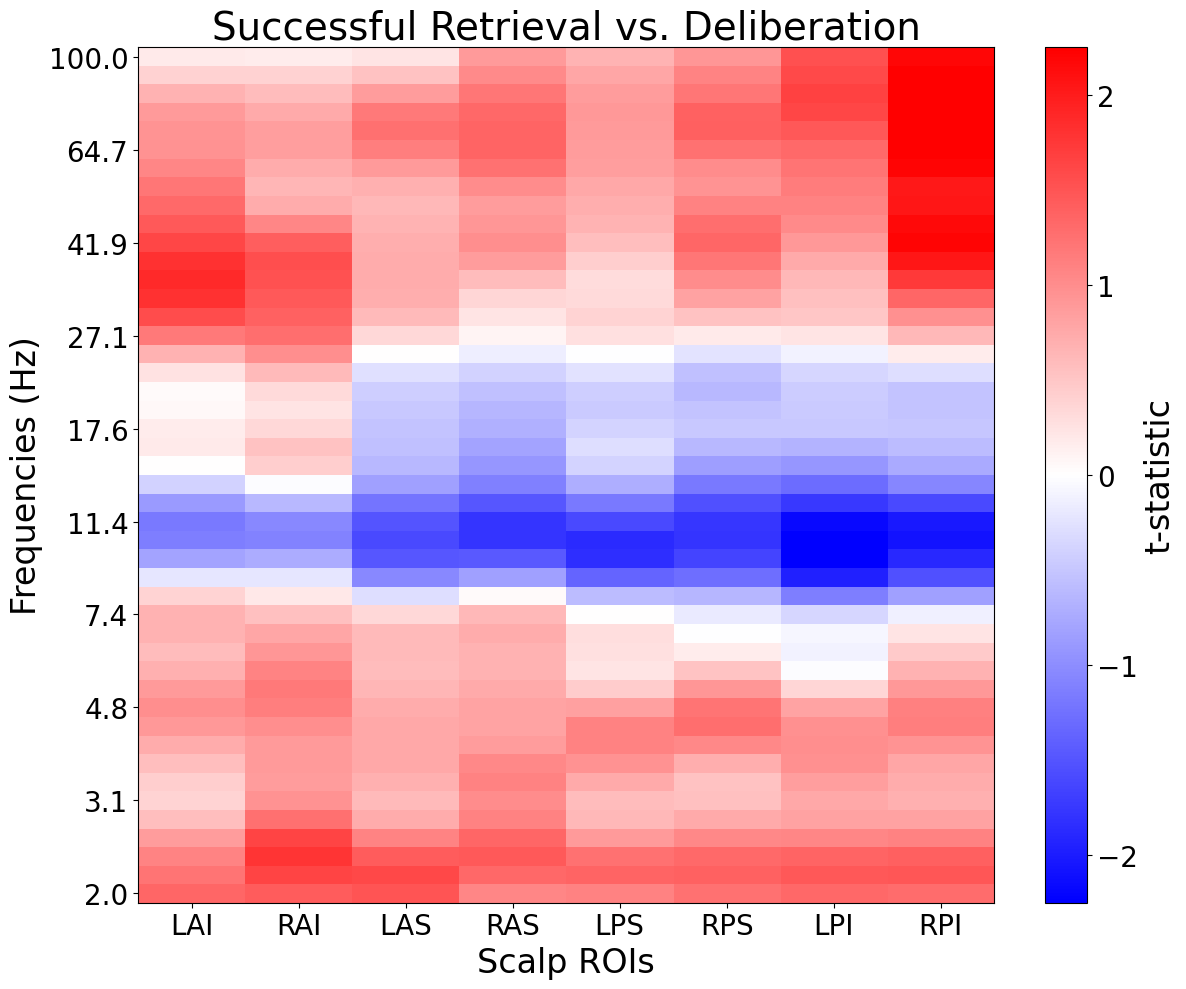

In [16]:
fig = plt.figure(figsize=(12, 10))
ax = plt.gca()
norm = mcolors.TwoSlopeNorm(vmin=-2.25, vcenter=0.0, vmax=2.25)
im = ax.imshow(heat_retr, cmap='bwr', aspect='auto', norm=norm)

freqs = heat_retr.index.values
tick_idx = np.unique(np.round(np.linspace(0, len(freqs)-1, 10)).astype(int))
ax.set_yticks(tick_idx)
ax.set_yticklabels([f'{freqs[i]:.1f}' for i in tick_idx], fontsize=20)

ax.set_xticks(range(heat_retr.shape[1]))
ax.set_xticklabels(list(heat_retr.columns), fontsize=20)

ax.set_xlabel('Scalp ROIs', fontsize=24)
ax.set_ylabel('Frequencies (Hz)', fontsize=24)
ax.set_title('Successful Retrieval vs. Deliberation', fontsize=28)

cbar = plt.colorbar(im, ax=ax, fraction=.1)
cbar.set_label('t-statistic', fontsize=24)
cbar.set_ticks([-2, -1, 0, 1, 2])
cbar.ax.tick_params(labelsize=20)

ax.invert_yaxis()
ax.grid(False)
plt.tight_layout()
plt.show()